### This notebook produces figure summarising the performance of the algorithms, their associated confusion matrix per ROI and a 3D visualisation of the ROI produced based on the nifti coordinates 

*Note: Prediction of visit 4 from visit 1 data, and visit 4 from visit 1,2,3 are performed in `classification_01` and saved in CSV. That needs to be run before this notebook can be run.* 

In [ ]:
import pandas as pd
from parcellation_to_classification_utils import *
from classification_functions import *

#PLease change according to your machine
user = "gaia"

/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/nilearn/input_data/__init__.py:27: FutureWarning: The import path 'nilearn.input_data' is deprecated in version 0.9. Importing from 'nilearn.input_data' will be possible at least until release 0.13.0. Please import from 'nilearn.maskers' instead.
  warnings.warn(message, FutureWarning)


In [2]:
#Retrieve paths used for analysis, path is based on user 
base_path, tian_atlas_path, tian_label_path, z_map_path, second_level_glm_path, run_mapping = obtain_base_paths(user)

# Load the Schaefer atlas 
schaefer_img, schaefer_labels = get_schaefer_parcellation(n_rois=200)

# Load the Tian atlas
tian_img, tian_labels = get_tian_parcellation(tian_atlas_path, tian_label_path)

# Combine the atlases
combined_img, combined_labels = combine_parcellations(schaefer_img, tian_img, schaefer_labels, tian_labels)

In [3]:
#Load ouput of FDR correction as pandas df
gbm_bh_all = pd.read_csv(os.path.join("Results", "Intermediate_Files", "FDR_corrected_fMRI_Classifier_Output",
                          "GradientBoostingClassifier", "gbm_bh_all_visits_FDRcorrected"))

svc_bh_all = pd.read_csv(os.path.join("Results", "Intermediate_Files", "FDR_corrected_fMRI_Classifier_Output",
                          "SVC", "svc_bh_all_visits_FDRcorrected"))

gbm_bh_early_pred = pd.read_csv(os.path.join("Results", "Intermediate_Files", "FDR_corrected_fMRI_Classifier_Output",
                          "GradientBoostingClassifier", "gbm_bh_early_pred_FDRcorrected"))

svc_bh_early_pred = pd.read_csv(os.path.join("Results", "Intermediate_Files", "FDR_corrected_fMRI_Classifier_Output",
                          "SVC", "svc_bh_early_pred_FDRcorrected"))

## Visualise CSVs summarising performance of algorithms

### GBM all visits

Right Visual Cortex
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/GBM/Right Visual Cortex_mask.nii.gz
Right Frontoparietal Control Network_4
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/GBM/Right Frontoparietal Control Network_4_mask.nii.gz
Right Dorsal Anterior Medial Thalamus
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/GBM/Right Dorsal Anterior Medial Thalamus_mask.nii.gz
Left Ventral Posterolateral Thalamus
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/GBM/Left Ventral Posterolateral Thalamus_mask.nii.gz
Right Frontoparietal Control Network_3
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/GBM/Right Frontoparietal Control Network_3_mask.nii.gz
Right Somatomotor Cortex
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/GBM/Right Somatomotor Cortex_mask.nii.gz
Right Parietal Cortex_7
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/GBM/Right Parietal Cortex_7_mask.nii.gz
Rig

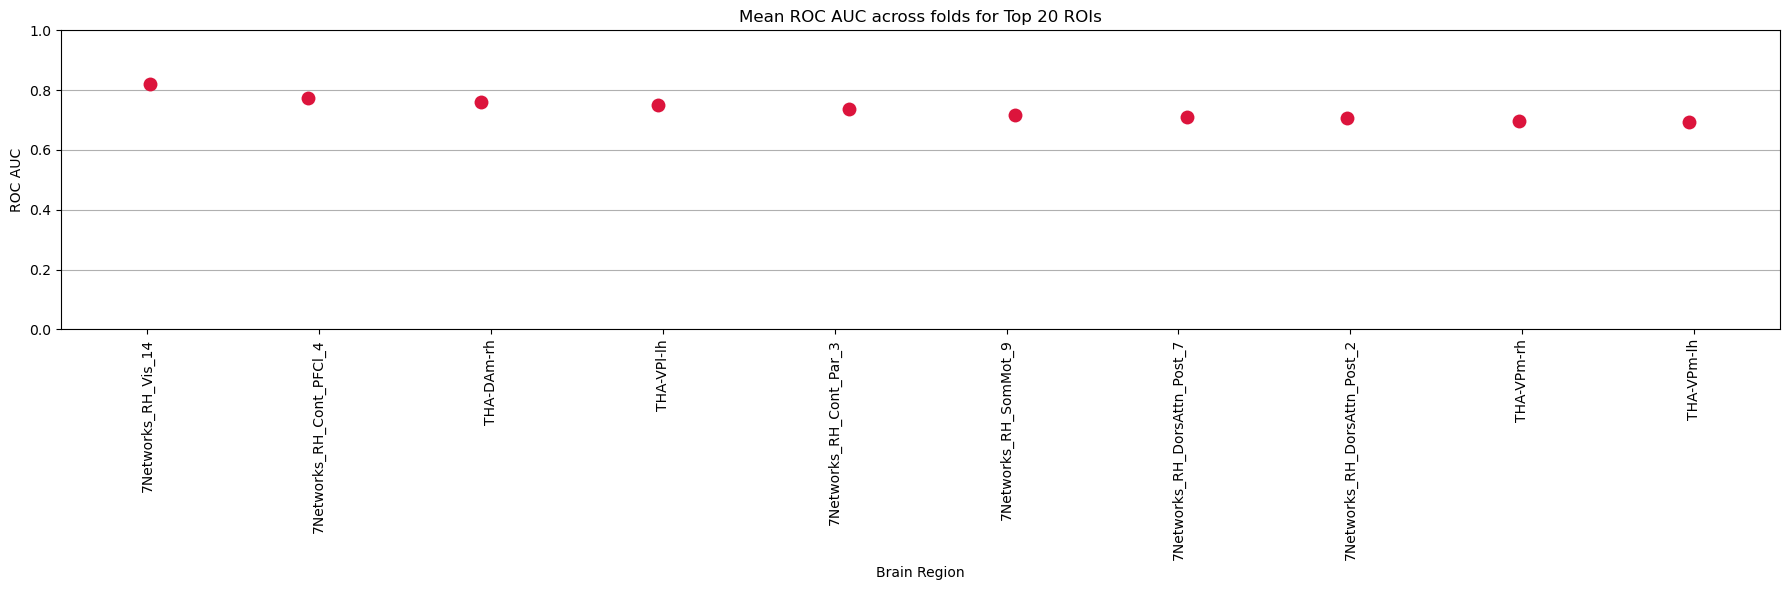

/homes/gp565/miniconda/envs/sbp_env/lib/python3.7/site-packages/nilearn/plotting/img_plotting.py:300: FutureWarning: Default resolution of the MNI template will change from 2mm to 1mm in version 0.10.0
  anat_img = load_mni152_template()


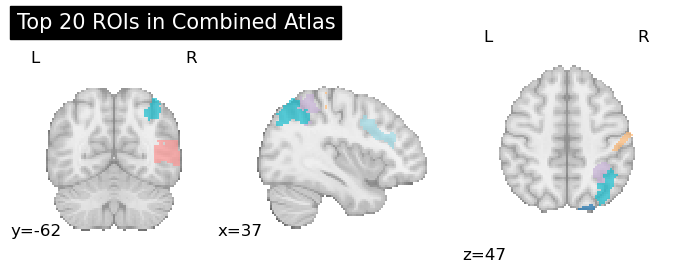

In [4]:
#Visualise top rois and save their nifti files to /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/*model_name*
gbm_bh_all = visualize_top_rois_from_performance_df(gbm_bh_all, base_path, combined_labels, combined_img, top_n=20,
                                           model = "GBM",
                                           save_nifti = True,
                                           plot_glass_brain = False,
                                           do_surface_plot = False)

### Show ROI surface plot and confusion matrix

#### Load nii files corresponding to every top ROI found by the SVC and GBM algorithms, both in case of all visits and early prediction. Render them in 3D using MRIcroGL. 

### SVC - all visits

Left Frontoparietal Control Network
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/SVC/Left Frontoparietal Control Network_mask.nii.gz
Right Parietal Cortex
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/SVC/Right Parietal Cortex_mask.nii.gz
Right Salience Ventral Attention Network
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/SVC/Right Salience Ventral Attention Network_mask.nii.gz
Left Dorsal Anterior Medial Thalamus
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/SVC/Left Dorsal Anterior Medial Thalamus_mask.nii.gz
Left Parietal Cortex_6
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/SVC/Left Parietal Cortex_6_mask.nii.gz
Left Parietal Cortex_8
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/SVC/Left Parietal Cortex_8_mask.nii.gz
Left Ventral Anterior Thalamus
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/SVC/Left Ventral Anterior Thalamus_mask.nii.gz
Right Frontoparietal 

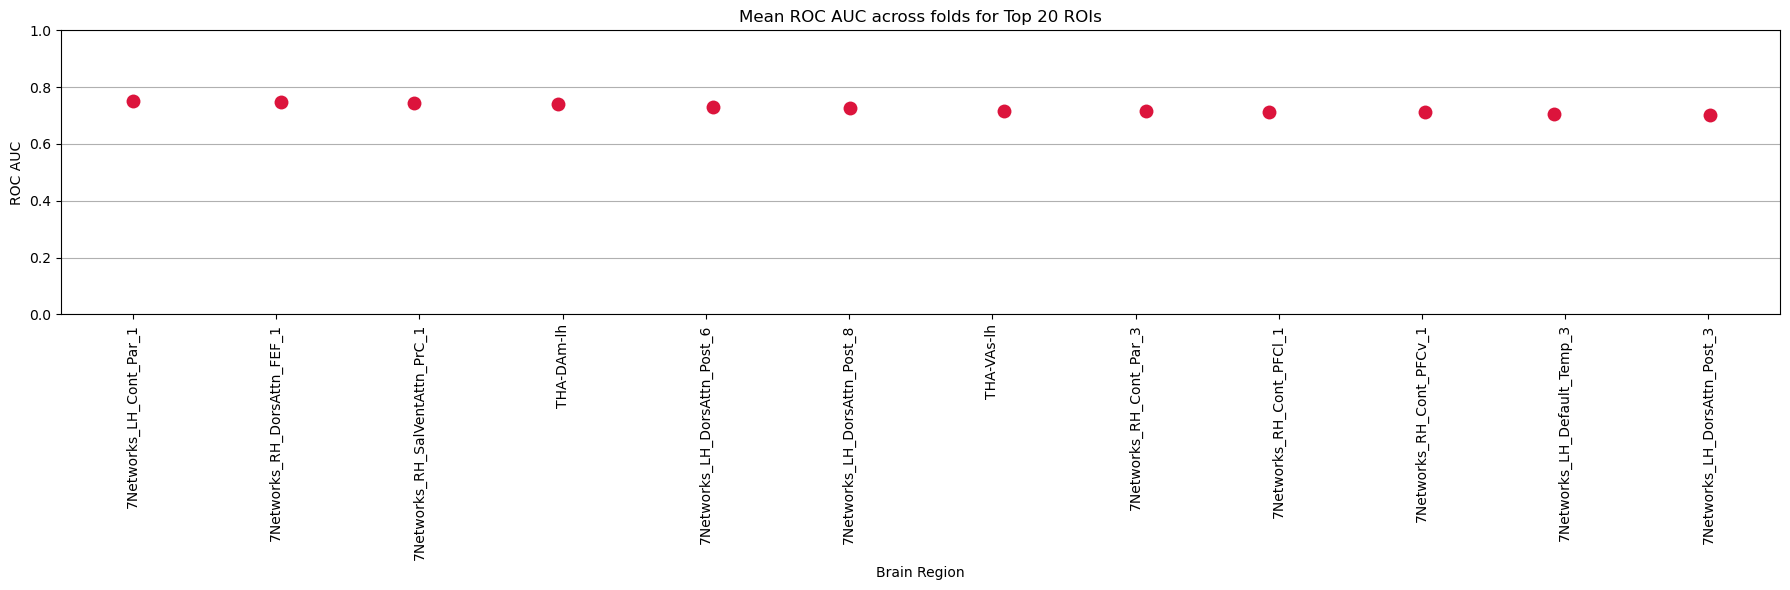

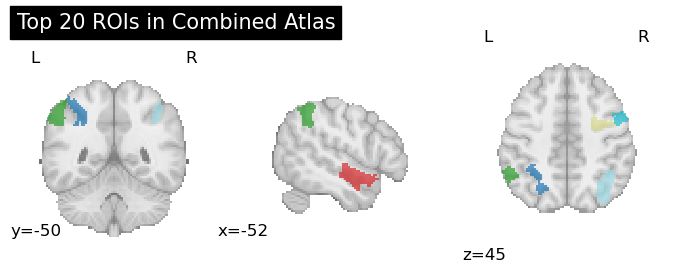

In [5]:
svc_bh_all = visualize_top_rois_from_performance_df(svc_bh_all, base_path, combined_labels, combined_img, top_n=20,
                                          model = "SVC",
                                           save_nifti = True,
                                           plot_glass_brain = False,
                                           do_surface_plot = False)

### GBM - early prediction

Left Dorsal Anterior Lateral Thalamus
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_GBM/Left Dorsal Anterior Lateral Thalamus_mask.nii.gz
Left Visual Cortex
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_GBM/Left Visual Cortex_mask.nii.gz
Left Frontoparietal Control Network
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_GBM/Left Frontoparietal Control Network_mask.nii.gz
Right Parietal Cortex
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_GBM/Right Parietal Cortex_mask.nii.gz
Left Middle Amygdala
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_GBM/Left Middle Amygdala_mask.nii.gz
Right Default Mode Network
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_GBM/Right Default Mode Network_mask.nii.gz
Left Default Mode Network
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_GBM/Left Default Mode Network_mask

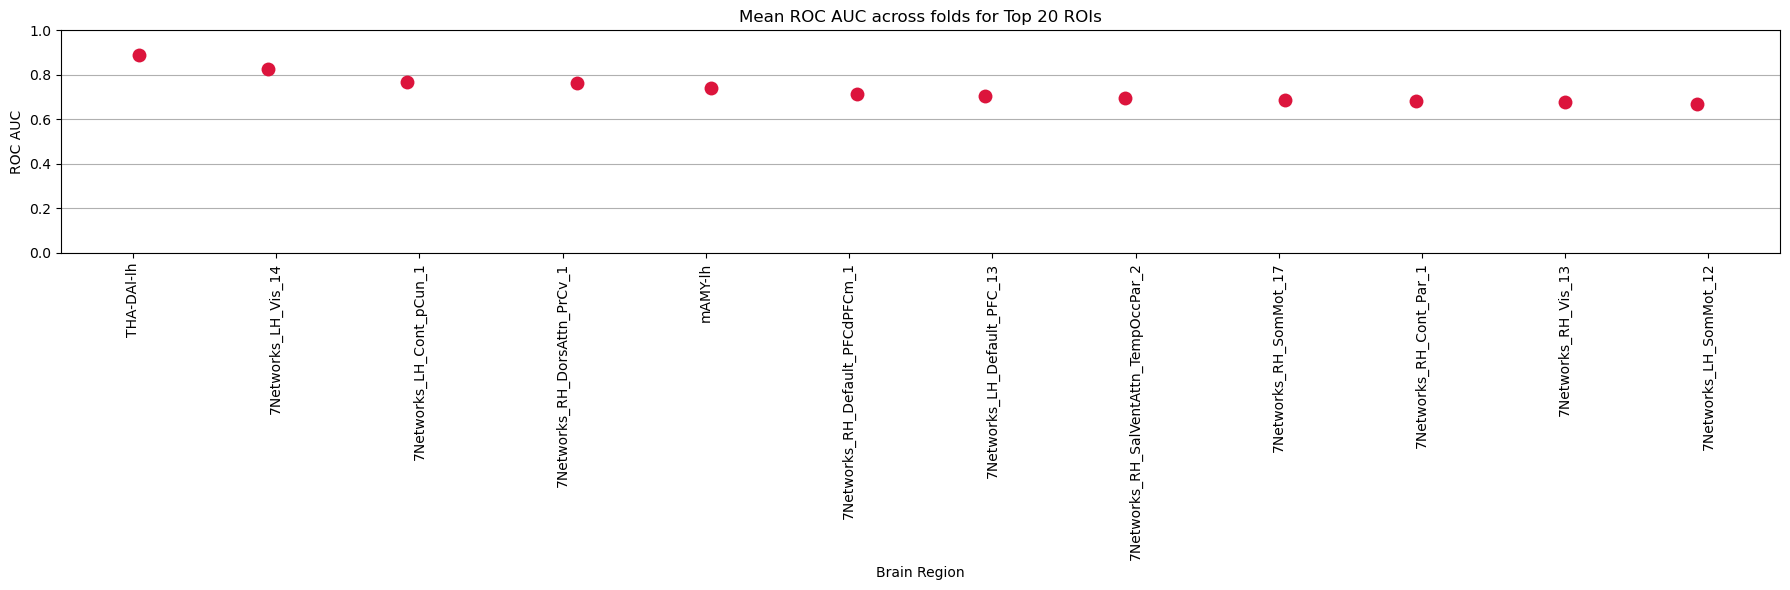

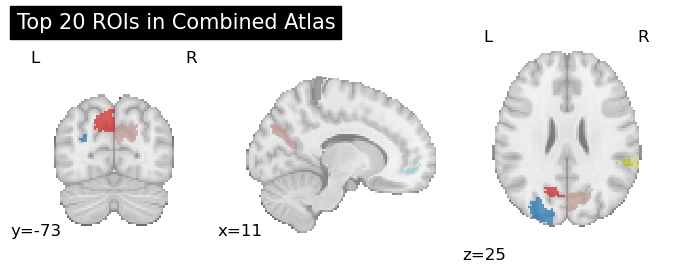

In [6]:
gbm_bh_early_pred = visualize_top_rois_from_performance_df(gbm_bh_early_pred, base_path, combined_labels, combined_img, top_n=20,
                                           model = "early_pred_GBM",
                                           save_nifti = True,
                                           plot_glass_brain = False,
                                           do_surface_plot = False)

### SVC- early prediction

Right Limbic System_2
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_SVC/Right Limbic System_2_mask.nii.gz
Right Visual Cortex_3
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_SVC/Right Visual Cortex_3_mask.nii.gz
Right Ventroposterior Putamen
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_SVC/Right Ventroposterior Putamen_mask.nii.gz
Left Limbic System_1
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_SVC/Left Limbic System_1_mask.nii.gz
Left Limbic System_4
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_SVC/Left Limbic System_4_mask.nii.gz
Left Visual Cortex
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_SVC/Left Visual Cortex_mask.nii.gz
Right Limbic System_1
Saved: /scratch/gp565/sbp/Results/Intermediate_Files/mz3_files/early_pred_SVC/Right Limbic System_1_mask.nii.gz
Right Visual Cortex_15
Saved: /scratch/gp565/sbp/Results

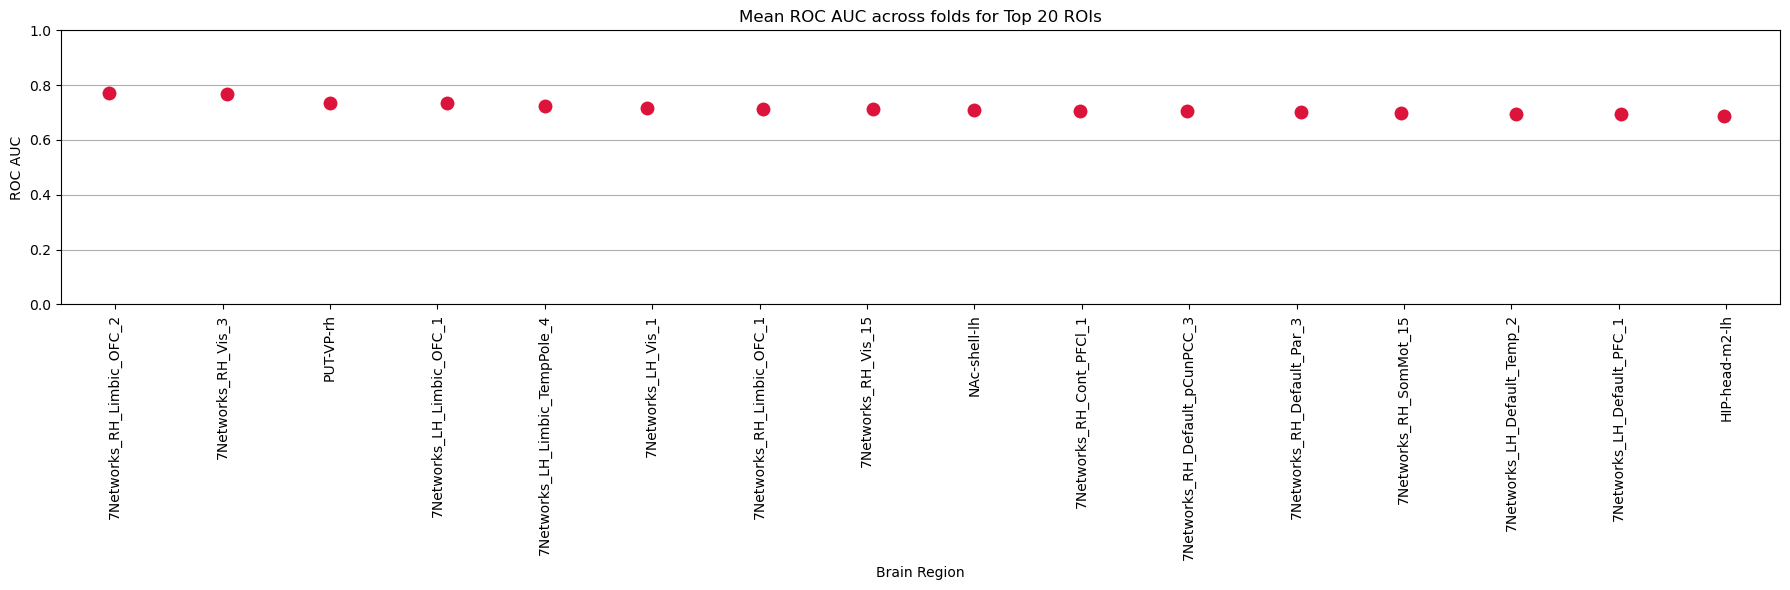

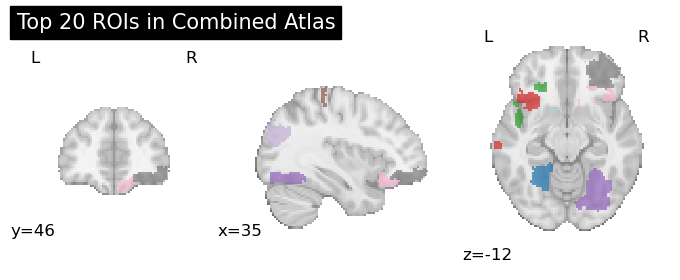

In [7]:
svc_bh_early_pred = visualize_top_rois_from_performance_df(svc_bh_early_pred, base_path, combined_labels, combined_img, top_n=20,
                                           model = "early_pred_SVC",
                                           save_nifti = True,
                                           plot_glass_brain = False,
                                           do_surface_plot = False)

### Add ROI labels by looking up the coordinates on FSLeyes and MRIcroGL 

In [9]:
extract_coordinates_from_nifti(base_path, model="GBM", type_prediction = "early_pred")


=== ROI Center MNI Coordinates ===



[('Left Default Mode Network', array([-9.31, 16.98, 63.17])),
 ('Left Dorsal Anterior Lateral Thalamus', array([-14.65, -19.67,  12.95])),
 ('Left Frontoparietal Control Network', array([ -9.53, -73.09,  37.43])),
 ('Left Middle Amygdala', array([-19.27,  -5.27, -16.28])),
 ('Left Somatomotor Cortex', array([-31.3 , -19.76,  63.84])),
 ('Left Visual Cortex', array([-23.09, -87.13,  24.01])),
 ('Right Default Mode Network', array([  4.91,  36.39, -14.03])),
 ('Right Frontoparietal Control Network', array([ 62.05, -37.48,  37.24])),
 ('Right Parietal Cortex', array([51.39, 10.61, 20.25])),
 ('Right Salience Ventral Attention Network', array([ 60.01, -38.6 ,  16.66])),
 ('Right Somatomotor Cortex', array([ 10.18, -39.07,  68.74])),
 ('Right Visual Cortex', array([ 11.3 , -73.77,  25.44]))]

### Construct mapping of anatomical names extracted from MRIcro and FSLeyes

In [10]:
gbm_all_mapping = {
            "Right Visual Cortex" : "V3A, R",
            "Right Frontoparietal Control Network_4" : "dmPFC, R",
            "Right Dorsal Anterior Medial Thalamus" : "DM-TH, R",
            "Left Ventral Posterolateral Thalamus" : "VP-TH, L",
            "Right Frontoparietal Control Network_3" : "PPC, R", 
            "Right Somatomotor Cortex" : "S1, R",
            "Right Parietal Cortex_7" : "SPC, R",
            "Right Parietal Cortex_2" : "TOC, R",
            "Right Ventral Posteromedial Thalamus" : "VPM-TH, R",
            "Left Ventral Posteromedial Thalamus" : "VPM-TH, L"
                }


svc_all_mapping = {
            "Left Frontoparietal Control Network" : "S1 & SMG, L",
            "Right Parietal Cortex" : "PMC, R",
            "Right Salience Ventral Attention Network" : "M1, R",
            "Left Dorsal Anterior Medial Thalamus" : "DM-TH, L",
            "Left Parietal Cortex_6" : "c", 
            "Left Parietal Cortex_8" : "PPC, L",
            "Left Ventral Anterior Thalamus" : "VA-TH, L",
            "Right Frontoparietal Control Network_3" : "PPC, R",
            "Right Frontoparietal Control Network_lateral1" : "OFC, R",
            "Right Frontoparietal Control Network_ventral1" : "aINS, R",
            "Left Default Mode Network" : "TC, L",
            "Left Parietal Cortex_3" : " SPC, L"
                }

gbm_early_pred_mapping = {
            "Left Dorsal Anterior Lateral Thalamus" : "TH, L",
            "Left Visual Cortex" : "VC, L",
            "Left Frontoparietal Control Network" : "PCu, L",
            "Right Parietal Cortex": "IFG(op), R", 
            "Left Middle Amygdala" : "MeA, L",
            "Right Default Mode Network" : "rMFC & PCC, R", 
            "Left Default Mode Network" : "SFG, L",
            "Right Salience Ventral Attention Network" : "SMG, R",
            "Right Somatomotor Cortex" : "S1, R",
            "Right Frontoparietal Control Network" : " SMG, R",
            "Right Visual Cortex" : "Cu, R", 
            "Left Somatomotor Cortex" : "M1, L"
                }


svc_early_pred_mapping = {
            "Right Limbic System_2" : "  OFC, R",
            "Right Visual Cortex_3" : "FG, R",
            "Right Ventroposterior Putamen" : "VP-PUT, R",
            "Left Limbic System_1" : "OFC, L",
            "Left Limbic System_4" : "aSTC, L",
            "Left Visual Cortex" : "LG, L", 
            "Right Limbic System_1" : " OFC, R",
            "Right Visual Cortex_15" : "V3, R",
            "Left Shell Nucleus Accumbens" : "NA, L",
            "Right Frontoparietal Control Network" : "OFC, R",
            "Right Default Mode Network" : "PCu, R",
            "Default Mode Network Parietal Region" : " V3, R", 
            "Right Somatomotor Cortex" : "S1-M1, R", #OR precentral gyrus
            "Left Default Mode Network_2" : "pMTG, L",
            "Left Default Mode Network_1" : " OFC, L",
            "Left Hippocampal Head, Medial Cluster 2" : "LHH-MC, L" #OR medial cluster 2
                }

### Get ROI labels and plot performance barplot

### All visits

GBM all visits
0       0 - V3A, R
1     0 - dmPFC, R
3     0 - DM-TH, R
2     0 - VP-TH, L
5       0 - PPC, R
6        0 - S1, R
4       0 - SPC, R
9       0 - TOC, R
7    0 - VPM-TH, R
8    0 - VPM-TH, L
Name: plot_label, dtype: object


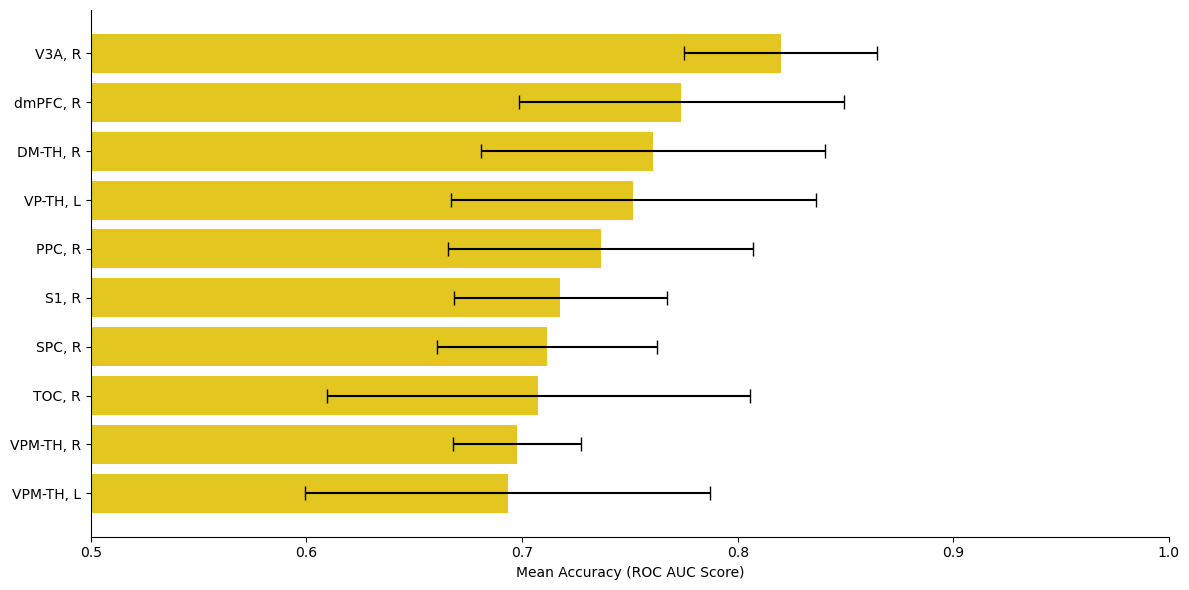

SVC all visits
0     0 - S1 & SMG, L
1          0 - PMC, R
2           0 - M1, R
4        0 - DM-TH, L
3               0 - c
5          0 - PPC, L
6        0 - VA-TH, L
7          0 - PPC, R
9          0 - OFC, R
10        0 - aINS, R
11          0 - TC, L
8         0 -  SPC, L
Name: plot_label, dtype: object


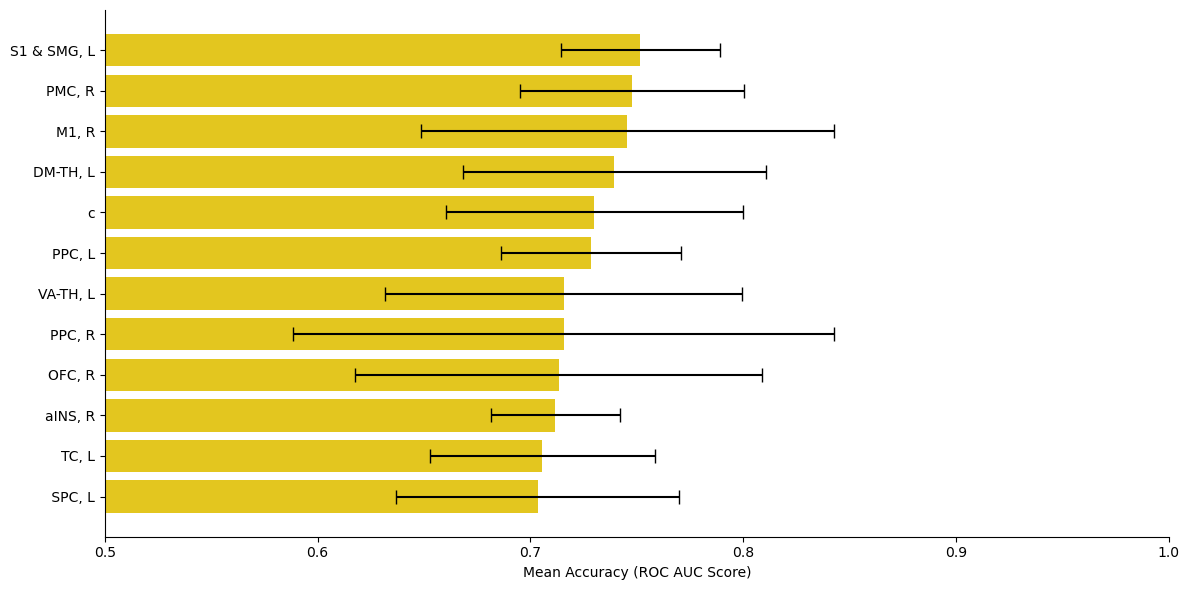

In [11]:
print("GBM all visits")
plot_human_labels(gbm_bh_all , base_path, gbm_all_mapping, model="GBM", prediction="all_visits", FDR_method="BH", error_bar = True)

print("SVC all visits")
plot_human_labels(svc_bh_all , base_path, svc_all_mapping, model="SVC", prediction="all_visits", FDR_method="BH", error_bar = True)

### Early prediction

GBM early prediction
0             0 - TH, L
1             0 - VC, L
2            0 - PCu, L
3        0 - IFG(op), R
4            0 - MeA, L
5     0 - rMFC & PCC, R
6            0 - SFG, L
7            0 - SMG, R
8             0 - S1, R
9           0 -  SMG, R
10            0 - Cu, R
11            0 - M1, L
Name: plot_label, dtype: object


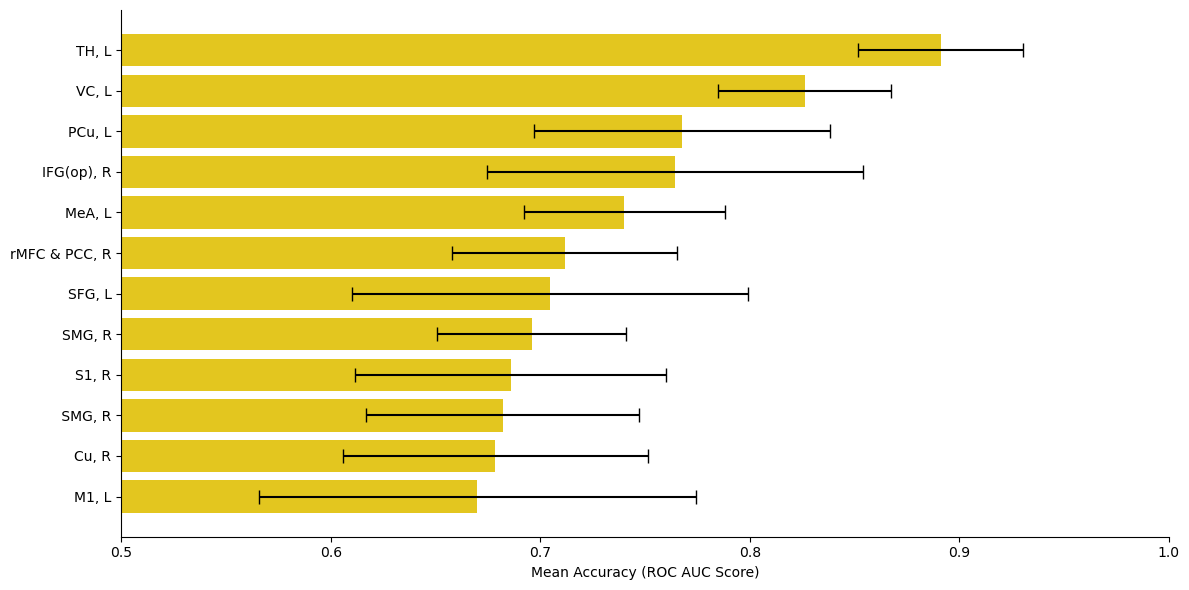

SVC early prediction
0      0 -   OFC, R
1         0 - FG, R
2     0 - VP-PUT, R
3        0 - OFC, L
4       0 - aSTC, L
5         0 - LG, L
6       0 -  OFC, R
7         0 - V3, R
8         0 - NA, L
9        0 - OFC, R
10       0 - PCu, R
11       0 -  V3, R
12     0 - S1-M1, R
13      0 - pMTG, L
14      0 -  OFC, L
15    0 - LHH-MC, L
Name: plot_label, dtype: object


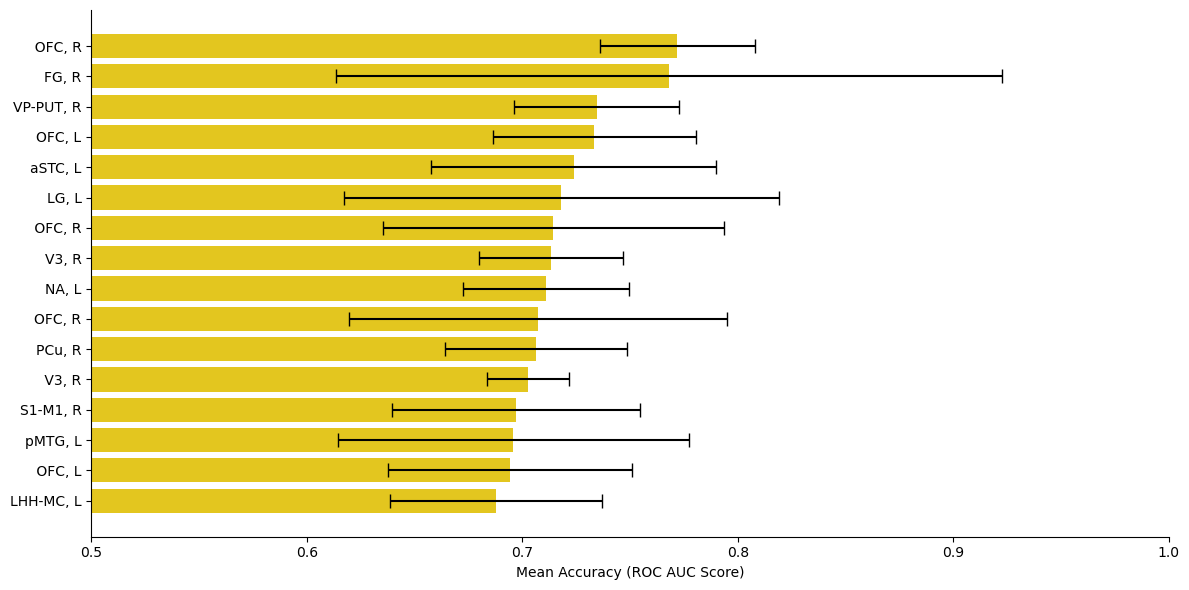

In [12]:
print("GBM early prediction")
plot_human_labels(gbm_bh_early_pred, base_path, gbm_early_pred_mapping, model="GBM", prediction="early_prediction", FDR_method="BH", error_bar = True)

print("SVC early prediction")
plot_human_labels(svc_bh_early_pred, base_path, svc_early_pred_mapping, model="SVC", prediction="early_prediction", FDR_method="BH", error_bar = True)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


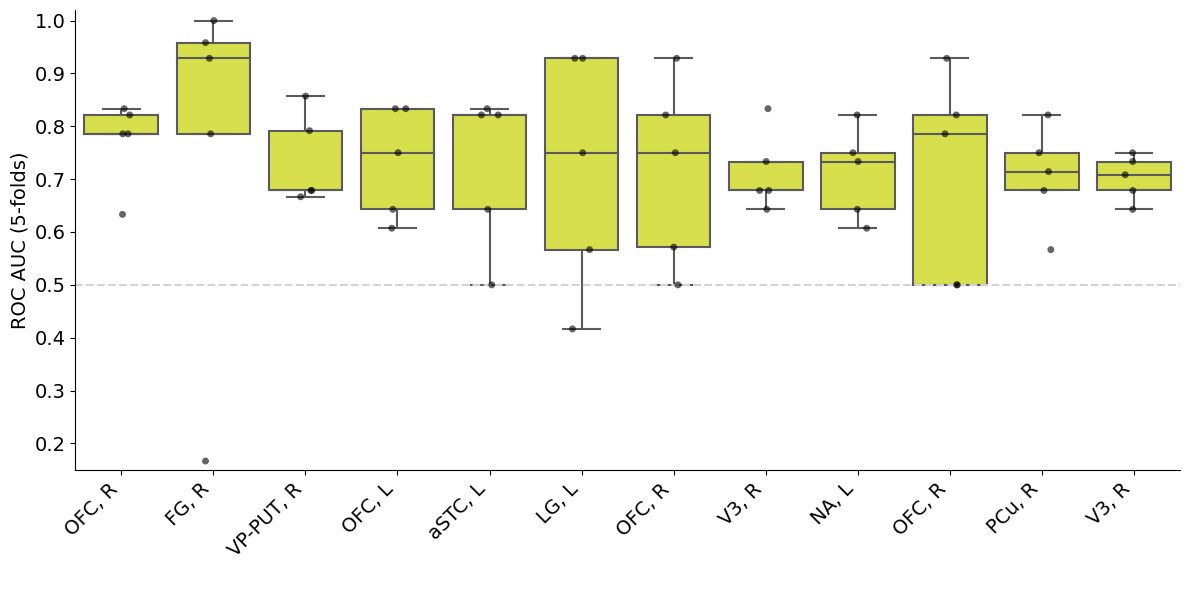

In [13]:
boxplot_ROC_AUC_performance(svc_bh_early_pred, "SVC")

### Get paths to surface plot

In [14]:
get_surface_plot_path(gbm_bh_all, base_path, model = "GBM", type_prediction="all_visits")
get_surface_plot_path(gbm_bh_early_pred, base_path, model = "GBM", type_prediction="early_prediction")

get_surface_plot_path(svc_bh_early_pred, base_path, model = "SVC", type_prediction="early_prediction")
get_surface_plot_path(svc_bh_all, base_path, model = "SVC", type_prediction="all_visits")

,brain_region,performance_stats,confusion_matrices,mean_performance,region_name,n_extreme,p_value,mean_over_folds,roi_anatomical_name,plot_label,surface_plot_path
0,7Networks_LH_Cont_Par_1,"{'mean': 0.751666666666666, 'std': 0.074981479...","[[[4, 0], [2, 4]], [[4, 0], [2, 3]], [[3, 1], ...",0.751667,Left Frontoparietal Control Network,9,0.009,0.751667,"S1 & SMG, L","0 - S1 & SMG, L",Left Frontoparietal Control Network_surface_pl...
1,7Networks_RH_DorsAttn_FEF_1,"{'mean': 0.7477777777777771, 'std': 0.10550291...","[[[4, 0], [1, 5]], [[3, 1], [1, 4]], [[2, 2], ...",0.747778,Right Parietal Cortex,17,0.017,0.747778,"PMC, R","0 - PMC, R",Right Parietal Cortex_surface_plot.png
2,7Networks_RH_SalVentAttn_PrC_1,"{'mean': 0.7455555555555551, 'std': 0.19399630...","[[[3, 1], [3, 3]], [[2, 2], [1, 4]], [[3, 1], ...",0.745556,Right Salience Ventral Attention Network,18,0.018,0.745556,"M1, R","0 - M1, R",Right Salience Ventral Attention Network_surfa...
4,THA-DAm-lh,"{'mean': 0.739444444444444, 'std': 0.142013736...","[[[2, 2], [0, 6]], [[3, 1], [1, 4]], [[3, 1], ...",0.739444,Left Dorsal Anterior Medial Thalamus,20,0.020,0.739444,"DM-TH, L","0 - DM-TH, L",Left Dorsal Anterior Medial Thalamus_surface_p...
3,7Networks_LH_DorsAttn_Post_6,"{'mean': 0.7300000000000001, 'std': 0.13964682...","[[[2, 2], [1, 5]], [[2, 2], [0, 5]], [[4, 0], ...",0.730000,Left Parietal Cortex_6,19,0.019,0.730000,c,0 - c,Left Parietal Cortex_6_surface_plot.png
5,7Networks_LH_DorsAttn_Post_8,"{'mean': 0.728333333333333, 'std': 0.084590516...","[[[3, 1], [0, 6]], [[3, 1], [1, 4]], [[4, 0], ...",0.728333,Left Parietal Cortex_8,30,0.030,0.728333,"PPC, L","0 - PPC, L",Left Parietal Cortex_8_surface_plot.png
6,THA-VAs-lh,"{'mean': 0.7155555555555551, 'std': 0.16811959...","[[[3, 1], [3, 3]], [[2, 2], [1, 4]], [[4, 0], ...",0.715556,Left Ventral Anterior Thalamus,34,0.034,0.715556,"VA-TH, L","0 - VA-TH, L",Left Ventral Anterior Thalamus_surface_plot.png
7,7Networks_RH_Cont_Par_3,"{'mean': 0.7155555555555551, 'std': 0.25420901...","[[[4, 0], [1, 5]], [[4, 0], [5, 0]], [[4, 0], ...",0.715556,Right Frontoparietal Control Network_3,37,0.037,0.715556,"PPC, R","0 - PPC, R",Right Frontoparietal Control Network_3_surface...
9,7Networks_RH_Cont_PFCl_1,"{'mean': 0.713333333333333, 'std': 0.191311264...","[[[3, 1], [2, 4]], [[1, 3], [0, 5]], [[3, 1], ...",0.713333,Right Frontoparietal Control Network_lateral1,43,0.043,0.713333,"OFC, R","0 - OFC, R",Right Frontoparietal Control Network_lateral1_...
10,7Networks_RH_Cont_PFCv_1,"{'mean': 0.711666666666666, 'std': 0.060715893...","[[[4, 0], [3, 3]], [[3, 1], [1, 4]], [[2, 2], ...",0.711667,Right Frontoparietal Control Network_ventral1,44,0.044,0.711667,"aINS, R","0 - aINS, R",Right Frontoparietal Control Network_ventral1_...


### Extract coordinates of each ROI's nifti file to plot 3D on MRIcroGL

In [15]:
top_rois_coords = extract_coordinates_from_nifti(base_path, model="GBM", type_prediction = "early_pred")

display(top_rois_coords)


=== ROI Center MNI Coordinates ===



[('Left Default Mode Network', array([-9.31, 16.98, 63.17])),
 ('Left Dorsal Anterior Lateral Thalamus', array([-14.65, -19.67,  12.95])),
 ('Left Frontoparietal Control Network', array([ -9.53, -73.09,  37.43])),
 ('Left Middle Amygdala', array([-19.27,  -5.27, -16.28])),
 ('Left Somatomotor Cortex', array([-31.3 , -19.76,  63.84])),
 ('Left Visual Cortex', array([-23.09, -87.13,  24.01])),
 ('Right Default Mode Network', array([  4.91,  36.39, -14.03])),
 ('Right Frontoparietal Control Network', array([ 62.05, -37.48,  37.24])),
 ('Right Parietal Cortex', array([51.39, 10.61, 20.25])),
 ('Right Salience Ventral Attention Network', array([ 60.01, -38.6 ,  16.66])),
 ('Right Somatomotor Cortex', array([ 10.18, -39.07,  68.74])),
 ('Right Visual Cortex', array([ 11.3 , -73.77,  25.44]))]

## Create confusion matrix and 3D surface plot for each top ROI found by the algorithm

GBM- all visits

/scratch/gp565/sbp/Hendrix_utils.py:1081: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


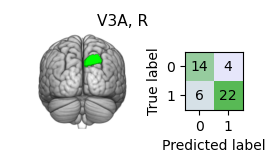

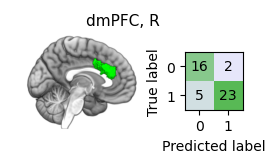

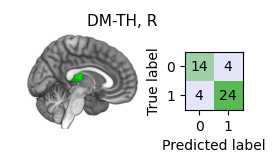

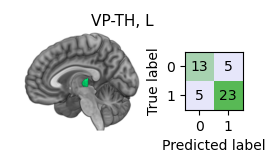

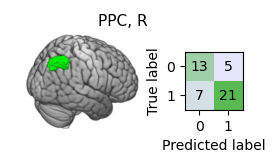

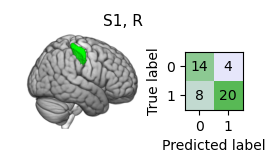

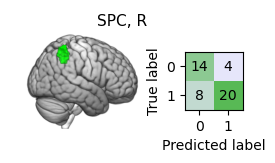

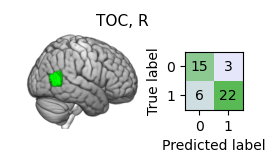

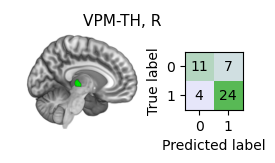

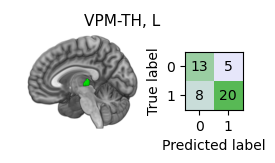

In [17]:
confusion_matrix_and_surface_plot_per_fold(gbm_bh_all, base_path, model = "GBM", type_prediction = "all_visits")

SVM - all visits

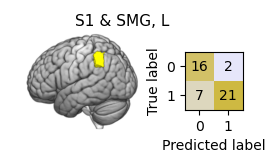

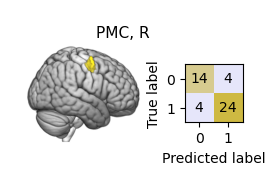

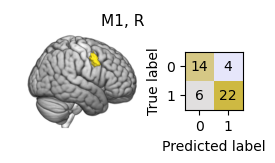

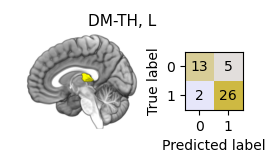

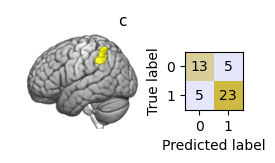

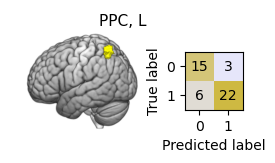

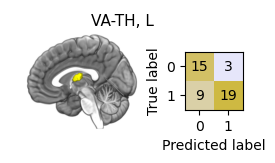

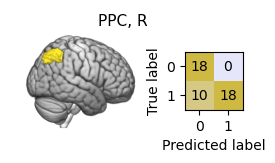

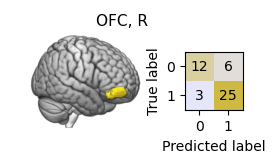

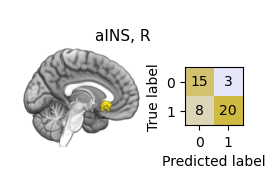

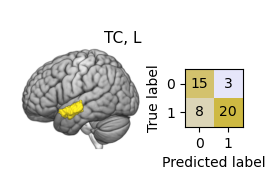

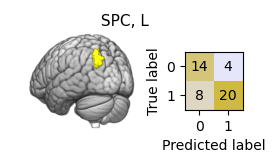

In [18]:
confusion_matrix_and_surface_plot_per_fold(svc_bh_all, base_path, model = "SVC", type_prediction = "all_visits")

SVC early prediction

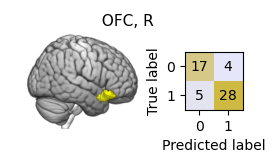

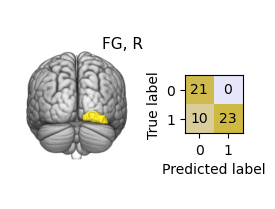

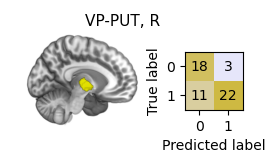

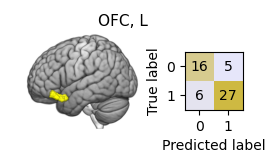

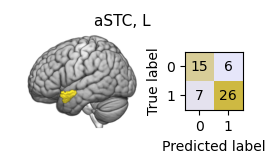

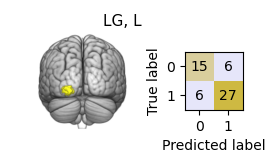

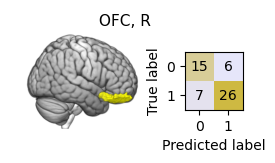

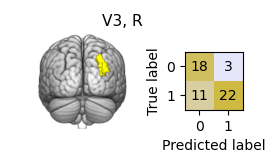

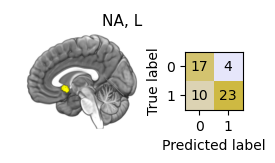

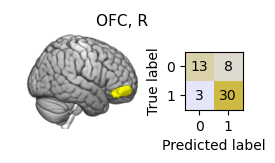

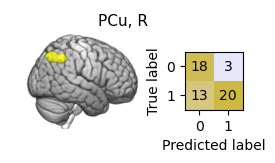

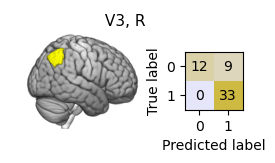

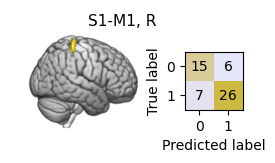

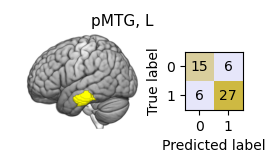

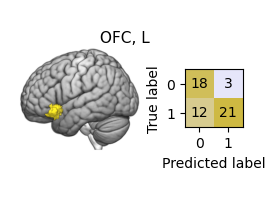

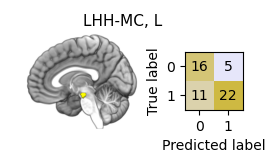

In [19]:
confusion_matrix_and_surface_plot_per_fold(svc_bh_early_pred, base_path, model = "SVC", type_prediction = "early_prediction")

GBM early prediction

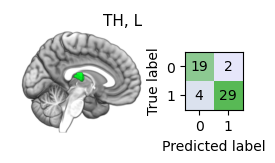

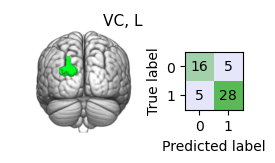

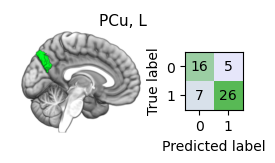

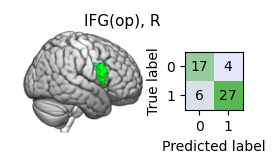

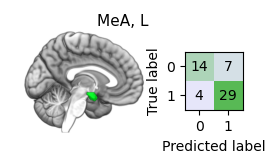

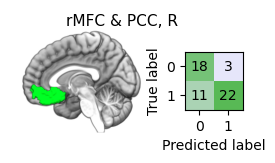

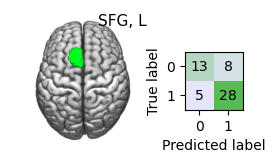

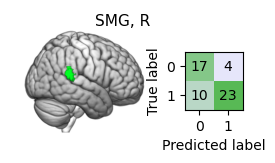

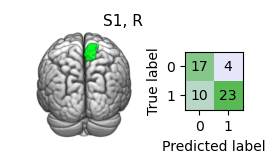

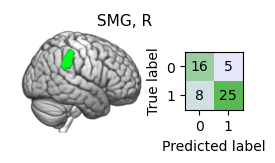

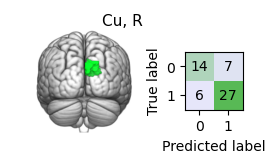

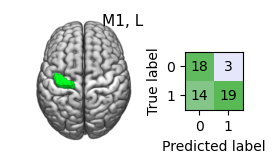

In [20]:
confusion_matrix_and_surface_plot_per_fold(gbm_bh_early_pred, base_path, model = "GBM", type_prediction = "early_prediction")